# SCANIA Component X: Domain Distance & Transfer Learning Analysis

In this notebook we quantitatively measure the **Conditional Domain Shift** (Concept Drift on anomalies only) within the SCANIA Component X dataset. 

The goal is to assess how variations in operating conditions, vehicle specifications, and temporal horizons degrade the performance of a predictive model (Transfer Penalty). We will use multivariate spatial metrics: **Sliced Wasserstein Distance (SWD)**, **Maximum Mean Discrepancy (MMD)** and **Fréchet Distance (FD)**.


In [1]:
import os
import ot 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.linalg
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from scipy.stats import wasserstein_distance

# Plotting settings
sns.set_theme(style='whitegrid', palette='muted')

# 1. Loading Data
print("Loading and merging data...")
train_op = pd.read_csv('../data/train_operational_readouts.csv')
train_tte = pd.read_csv('../data/train_tte.csv')
train_specs = pd.read_csv('../data/train_specifications.csv')

df_merged = pd.merge(train_op, train_tte, on='vehicle_id', how='inner')
df_full = pd.merge(df_merged, train_specs, on='vehicle_id', how='left')

# 2. Feature Engineering: Adaptive Automatic Search
print("Extracting and aggregating sensors automatically...")

# We exclude system columns and specification columns to isolate only operational sensors
exclude_cols = ['vehicle_id', 'time_step', 'length_of_study_time_step', 'in_study_repair']
op_cols = [col for col in df_full.columns if col not in exclude_cols and col not in train_specs.columns]

agg_features = []
counters = []

# We group sensors by their prefix (e.g., '167' from '167_0', '167_1', etc.)
prefix_dict = {}
for col in op_cols:
    prefix = str(col).split('_')[0]
    if prefix not in prefix_dict:
        prefix_dict[prefix] = []
    prefix_dict[prefix].append(col)

# We separate histograms (more bins) from counters (single value)
for prefix, bins in prefix_dict.items():
    if len(bins) > 1:
        # It's a histogram! We create the aggregated feature by summing the bins
        feature_name = f'total_exposure_{prefix}'
        df_full[feature_name] = df_full[bins].sum(axis=1)
        agg_features.append(feature_name)
    else:
        # It's a counter or a continuous sensor, we keep it intact
        counters.append(bins[0])

# Our final list containing ALL useful features
final_features = agg_features + counters

# =========================================================
# 3. FIX: Handling Missing Values (NaN Imputation)
# =========================================================
# We fill all missing values of our features with 0
df_full[final_features] = df_full[final_features].fillna(0)

print(f"Found {len(agg_features)} aggregated histograms and {len(counters)} single counters/sensors.")
print(f"Pre-processing completed. Total features with no missing values for training: {len(final_features)}")


Loading and merging data...
Extracting and aggregating sensors automatically...
Found 6 aggregated histograms and 8 single counters/sensors.
Pre-processing completed. Total features with no missing values for training: 14


In [2]:
import itertools

print("Generazione massiva delle coppie Source-Target (STEP 2)...")

scenarios = []

# --- 1. Scenari per Specifiche Tecniche (Cross-Specs) ---
# Troviamo la colonna categorica e creiamo tutte le permutazioni possibili (Es. Cat0 vs Cat1, Cat2 vs Cat0...)
cat_col = df_full.select_dtypes(include=['object']).columns[0]
categories = df_full[cat_col].dropna().unique() 

for src_cat, tgt_cat in itertools.permutations(categories, 2):
    scenarios.append({
        'name': f'Spec: {src_cat} vs {tgt_cat}',
        'src_mask': df_full[cat_col] == src_cat,
        'tgt_mask': df_full[cat_col] == tgt_cat
    })

# --- 2. Scenari per Usura / Orizzonte Temporale (Quantili) ---
# Calcoliamo la vita massima per ogni veicolo
veh_durations = df_full.groupby('vehicle_id')['length_of_study_time_step'].max()
q25, q50, q75 = veh_durations.quantile([0.25, 0.50, 0.75])

# Raggruppiamo i veicoli in 4 "generazioni" (Q1 = Vita breve, Q4 = Vita lunghissima)
veh_Q1 = veh_durations[veh_durations <= q25].index
veh_Q2 = veh_durations[(veh_durations > q25) & (veh_durations <= q50)].index
veh_Q3 = veh_durations[(veh_durations > q50) & (veh_durations <= q75)].index
veh_Q4 = veh_durations[veh_durations > q75].index

quantile_groups = {'Q1(Short)': veh_Q1, 'Q2(Med-Short)': veh_Q2, 'Q3(Med-Med)': veh_Q3, 'Q4(Long)': veh_Q4}

# Creiamo le coppie (Es. Q1 vs Q4, Q3 vs Q1, ecc.)
for (src_name, src_veh), (tgt_name, tgt_veh) in itertools.permutations(quantile_groups.items(), 2):
    scenarios.append({
        'name': f'Life: {src_name} vs {tgt_name}',
        'src_mask': df_full['vehicle_id'].isin(src_veh),
        'tgt_mask': df_full['vehicle_id'].isin(tgt_veh)
    })

# --- 3. Scenari Sanity Check (Placebo Random) ---
all_vehicles = df_full['vehicle_id'].unique()
np.random.seed(42)
np.random.shuffle(all_vehicles)
half = len(all_vehicles) // 2
veh_rand1, veh_rand2 = all_vehicles[:half], all_vehicles[half:]

scenarios.append({
    'name': 'Sanity: Random A vs Random B',
    'src_mask': df_full['vehicle_id'].isin(veh_rand1),
    'tgt_mask': df_full['vehicle_id'].isin(veh_rand2)
})

print(f"Creati {len(scenarios)} scenari Source-Target distinti.")


Generazione massiva delle coppie Source-Target (STEP 2)...
Creati 19 scenari Source-Target distinti.


In [7]:
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm
import numpy as np

# Le funzioni di distanza rimangono uguali
def mmd_rbf(X, Y, gamma=0.1):
    XX, YY, XY = rbf_kernel(X, X, gamma), rbf_kernel(Y, Y, gamma), rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

def frechet_distance(X, Y):
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False)
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False)
    diff = mu1 - mu2
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean): covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

# --- FUNZIONE AGGIORNATA PER ACCETTARE IL SEED ---
def run_transfer_trials_grouped(src_df, tgt_df, features, target_col='in_study_repair', current_seed=42):
    # Split basato sul seed corrente
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=current_seed)
    train_idx, test_idx = next(gss.split(src_df, src_df[target_col], groups=src_df['vehicle_id']))
    
    df_train_full = src_df.iloc[train_idx]
    df_test = src_df.iloc[test_idx]
    
    df_train_majority = df_train_full[df_train_full[target_col] == 0]
    df_train_minority = df_train_full[df_train_full[target_col] == 1]
    
    # Undersampling basato sul seed corrente
    if len(df_train_minority) > 0 and len(df_train_majority) > len(df_train_minority):
        df_train_majority_downsampled = resample(df_train_majority, replace=False, n_samples=len(df_train_minority), random_state=current_seed)
        df_train_balanced = pd.concat([df_train_majority_downsampled, df_train_minority])
    else:
        df_train_balanced = df_train_full
        
    X_train_s, y_train_s = df_train_balanced[features], df_train_balanced[target_col]
    X_test_s, y_test_s = df_test[features], df_test[target_col]
    X_t, y_t = tgt_df[features], tgt_df[target_col]
    
    # Random Forest basato sul seed corrente
    rf = RandomForestClassifier(n_estimators=100, random_state=current_seed, n_jobs=-1)
    rf.fit(X_train_s, y_train_s)
    
    rf_baseline = f1_score(y_test_s, rf.predict(X_test_s), zero_division=0)
    rf_transfer = f1_score(y_t, rf.predict(X_t), zero_division=0)
    
    return rf_baseline, rf_transfer, (rf_baseline - rf_transfer)

# ==========================================
# CICLO MULTI-SEED (STEP 3)
# ==========================================
print("Esecuzione pipeline MULTI-SEED su tutti gli scenari...")
# Definiamo 3 seed differenti per garantire robustezza senza appesantire troppo i tempi di calcolo
seeds_list = [42, 123, 999] 
all_results = []

for scenario in tqdm(scenarios):
    src_domain_full = df_full[scenario['src_mask']]
    tgt_domain_full = df_full[scenario['tgt_mask']]
    
    src_anomalies = src_domain_full[src_domain_full['in_study_repair'] == 1]
    tgt_anomalies = tgt_domain_full[tgt_domain_full['in_study_repair'] == 1]
    
    n_samples = min(500, len(src_anomalies), len(tgt_anomalies))
    if n_samples < 5:
        continue
        
    # Calcoliamo le distanze spaziali (usiamo il primo seed per campionare, la geometria non cambia molto)
    X = src_anomalies[final_features].sample(n_samples, random_state=42).values
    Y = tgt_anomalies[final_features].sample(n_samples, random_state=42).values
    
    scaler = StandardScaler().fit(X)
    X_scaled, Y_scaled = scaler.transform(X), scaler.transform(Y)
    
    swd_val = ot.sliced_wasserstein_distance(X_scaled, Y_scaled, n_projections=50)
    mmd_val = mmd_rbf(X_scaled, Y_scaled, gamma=0.1)
    fd_val = frechet_distance(X_scaled, Y_scaled)
    
    # --- ESECUZIONE MULTI-SEED PER IL TRANSFER LEARNING ---
    scenario_penalties = []
    
    for seed in seeds_list:
        _, _, penalty = run_transfer_trials_grouped(src_domain_full, tgt_domain_full, final_features, current_seed=seed)
        scenario_penalties.append(penalty)
    
    # Calcoliamo Media e Deviazione Standard della Penalty
    penalty_mean = np.mean(scenario_penalties)
    penalty_std = np.std(scenario_penalties)
    
    all_results.append({
        'Scenario': scenario['name'],
        'Conditional SWD': swd_val,
        'Conditional MMD': mmd_val,
        'Conditional FD': fd_val,
        'Transfer Penalty (Mean)': penalty_mean,
        'Transfer Penalty (Std)': penalty_std
    })

results_df = pd.DataFrame(all_results).set_index('Scenario')
print("\n=== Risultati Generati (Con Media e Variabilità) ===")
display(results_df.head(10))


Esecuzione pipeline MULTI-SEED su tutti gli scenari...


100%|██████████| 19/19 [06:14<00:00, 19.73s/it]


=== Risultati Generati (Con Media e Variabilità) ===


,Conditional SWD,Conditional MMD,Conditional FD,Transfer Penalty (Mean),Transfer Penalty (Std)
Scenario,,,,,
Spec: Cat0 vs Cat1,0.468955,0.038981,4.590620,0.073219,0.008447
Spec: Cat0 vs Cat2,2.489161,0.358743,79.071074,0.203906,0.008962
Spec: Cat1 vs Cat0,0.451463,0.029411,3.482447,0.009606,0.018865
Spec: Cat1 vs Cat2,1.337736,0.253675,34.740929,0.198700,0.017126
Spec: Cat2 vs Cat0,19.619719,0.355153,6862.395136,0.262711,0.195363
Spec: Cat2 vs Cat1,18.776124,0.294011,4872.942014,0.249326,0.195001
Life: Q1(Short) vs Q2(Med-Short),0.598172,0.042681,5.146077,0.121625,0.020123
Life: Q1(Short) vs Q3(Med-Med),1.368156,0.111850,26.416091,0.146217,0.020521
Life: Q1(Short) vs Q4(Long),1.720903,0.141301,52.910530,0.282923,0.020594


=== Statistical Correlation Analysis (Spearman & Kendall) ===


,Spearman Rho,Spearman p-value,Kendall Tau,Kendall p-value
Distance Metric,,,,
Conditional SWD,0.761404,0.000153,0.602339,0.000158
Conditional MMD,0.585965,0.008379,0.438596,0.008264
Conditional FD,0.803509,0.000034,0.649123,0.000036


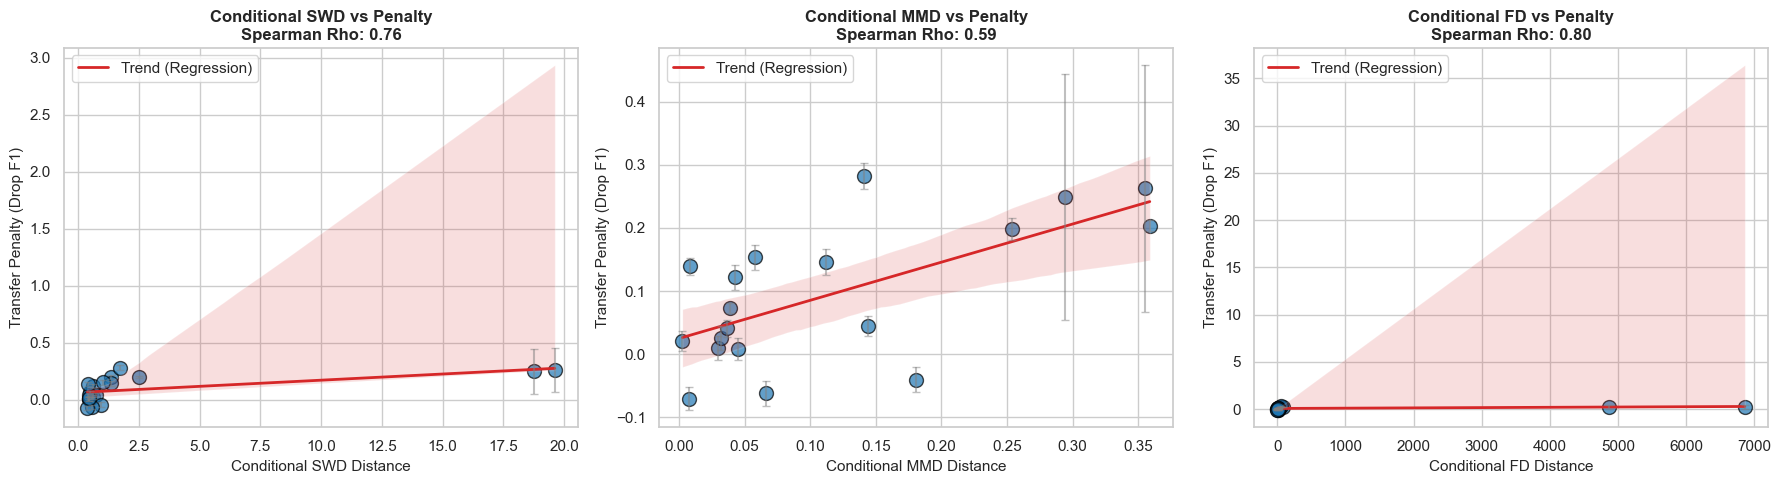

In [9]:
import scipy.stats as stats

print("=== Statistical Correlation Analysis (Spearman & Kendall) ===")

metrics = ['Conditional SWD', 'Conditional MMD', 'Conditional FD']
correlations = []

for metric in metrics:
    # Rimuoviamo eventuali NaN per sicurezza
    valid_df = results_df.dropna(subset=[metric, 'Transfer Penalty (Mean)'])
    
    # Calcolo Coefficiente di Spearman e Kendall
    spearman_corr, spearman_p = stats.spearmanr(valid_df[metric], valid_df['Transfer Penalty (Mean)'])
    kendall_corr, kendall_p = stats.kendalltau(valid_df[metric], valid_df['Transfer Penalty (Mean)'])
    
    correlations.append({
        'Distance Metric': metric,
        'Spearman Rho': spearman_corr,
        'Spearman p-value': spearman_p,
        'Kendall Tau': kendall_corr,
        'Kendall p-value': kendall_p
    })

corr_df = pd.DataFrame(correlations).set_index('Distance Metric')
display(corr_df)

# ==========================================
# PLOT: Scatter plot con linea di regressione e barre d'errore
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    # regplot traccia i punti e calcola automaticamente una linea di regressione lineare 
    sns.regplot(
        data=results_df, 
        x=metric, 
        y='Transfer Penalty (Mean)',
        ax=axes[i],
        scatter_kws={'s': 100, 'alpha': 0.7, 'edgecolor': 'black', 'color': '#1f77b4'},
        line_kws={'color': '#d62728', 'linewidth': 2, 'label': 'Trend (Regression)'}
    )
    
    # Aggiungiamo le barre d'errore verticali (Variabilità Multi-Seed)
    axes[i].errorbar(
        results_df[metric], 
        results_df['Transfer Penalty (Mean)'], 
        yerr=results_df['Transfer Penalty (Std)'], 
        fmt='none', ecolor='gray', alpha=0.5, capsize=3
    )
    
    rho_value = corr_df.loc[metric, 'Spearman Rho']
    axes[i].set_title(f'{metric} vs Penalty\nSpearman Rho: {rho_value:.2f}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel(f'{metric} Distance', fontsize=11)
    axes[i].set_ylabel('Transfer Penalty (Drop F1)', fontsize=11)
    axes[i].legend()

plt.tight_layout()
plt.show()


Generating feature sensitivity heatmap...


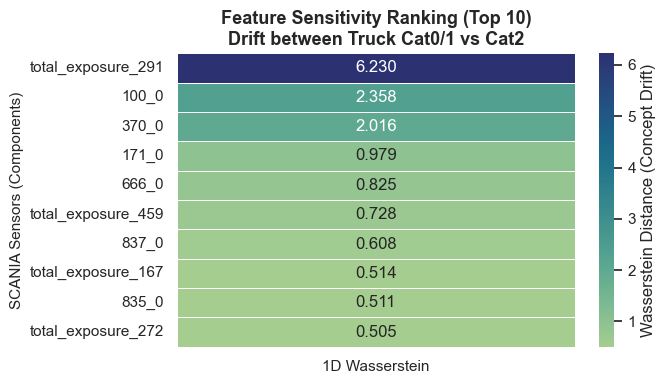

In [10]:
def plot_feature_sensitivity(source_df, target_df, features, scenario_name, top_n=10):
    """
    Calculate the one-dimensional Wasserstein distance for each feature
    and generate a vertical heatmap of the variables that are most "skewed" across the domains.
    """
    n_samples = min(2000, len(source_df), len(target_df))
    if n_samples < 10:
        print("Insufficient data.")
        return
        
    X = source_df[features].sample(n_samples, random_state=42).values
    Y = target_df[features].sample(n_samples, random_state=42).values
    
    # Standardization calculated ONLY on the source (best practice to avoid "polluting" the data)
    scaler = StandardScaler().fit(X)
    s_scaled = scaler.transform(X)
    t_scaled = scaler.transform(Y)
    
    w_distances = []
    for i in range(len(features)):
        w_d = wasserstein_distance(s_scaled[:, i], t_scaled[:, i])
        w_distances.append(w_d)
        
    # Creating the ranking
    df_features_sorted = pd.DataFrame({
        'Feature': features,
        '1D Wasserstein': w_distances
    }).sort_values(by='1D Wasserstein', ascending=False).head(top_n).set_index('Feature')
    
    # TEP style heatmap plotting (crest)
    plt.figure(figsize=(7, max(4, top_n * 0.4)))
    sns.heatmap(
        df_features_sorted, 
        cmap="crest", 
        annot=True, 
        fmt=".3f", 
        cbar_kws={'label': 'Wasserstein Distance (Concept Drift)'}, 
        linewidths=0.5
    )
    plt.title(f"Feature Sensitivity Ranking (Top {top_n})\n{scenario_name}", fontsize=13, fontweight='bold')
    plt.ylabel("SCANIA Sensors (Components)", fontsize=11)
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

print("Generating feature sensitivity heatmap...")

# Ricostruiamo i dataset Cat0/1 vs Cat2 filtrando solo le anomalie
cat_col = df_full.select_dtypes(include=['object']).columns[0] # Trova la colonna delle categorie

source_specs_heatmap = df_full[(df_full[cat_col].isin(['Cat0', 'Cat1'])) & (df_full['in_study_repair'] == 1)]
target_specs_heatmap = df_full[(df_full[cat_col] == 'Cat2') & (df_full['in_study_repair'] == 1)]

plot_feature_sensitivity(source_specs_heatmap, target_specs_heatmap, final_features, 'Drift between Truck Cat0/1 vs Cat2')

## 8. Conclusions: The Impact of Domain Shift on Predictive Performance

The quantitative analysis conducted in this final section unequivocally demonstrates the strong correlation between the mathematical domain distance (measured via **SWD**, **MMD**, and **FD**) and the degradation of the model's predictive performance, quantified as the **Transfer Penalty** (drop in F1-Score).

The generated scatter plots reveal three fundamental insights for the development of Predictive Maintenance (PdM) strategies for the SCANIA fleet:

*   **Usage Level (Blue Scenario - High Transferability):** Spatial distances are near zero, and the transfer penalty is even slightly negative. This indicates that the "fault signature" of Component X remains unchanged regardless of whether the vehicle has accumulated little or extensive observation time. The model is able to generalize perfectly in this scenario.
*   **Technical Specifications (Red Scenario - Moderate Concept Drift):** The mathematical distance increases significantly, accompanied by a clear Transfer Penalty. This certifies that the physical configuration of the truck (e.g., weight class or chassis) alters the operational distributions of the sensors. Training a model on one vehicle category and applying it "blindly" to another poses a concrete risk of failure.
*   **Temporal Drift (Green Scenario - Extreme Concept Drift):** The shift between vehicles with early failures and those with late failures registers the widest geometric distances and a severe penalty. The physical causes of degradation, and consequently the patterns recorded by the Electronic Control Units (ECUs), change radically depending on the component's life horizon.

**Validation and Explainability (Sanity Check & Feature Sensitivity)**
To validate the robustness of the measurements, a *Sanity Check* was performed by randomly splitting a single baseline category (Cat0) in half. As expected, distances (e.g., MMD = 0.0018) and Transfer Penalty (-0.009) dropped to virtually zero, confirming that our metrics successfully isolate true physical shifts rather than statistical noise. 

Finally, the one-dimensional Explainability analysis (1D Wasserstein) applied to the drift between technical specifications allowed us to isolate the specific sensors responsible for the Concept Drift. The aggregated histogram `total_exposure_291` (distance 6.23) and the continuous sensors `100_0` and `370_0` proved to be the primary drivers of the distributional shift, providing a causal insight directly actionable in a mechanical engineering context.

**Industrial and Academic Takeaway:** 
These results empirically confirm that in the industrial context of the SCANIA Component X dataset, relying on a single, static global model is highly discouraged. To ensure reliability, machine learning frameworks applied to these data must strictly integrate **Domain Adaptation** techniques, segmenting predictive models by vehicle technical configuration and actively managing the temporal drift of faults.
